# Execution cost research

1. Build a USD-notional size grid (comparable across symbols);
2. Sweep **buy** and **sell** residual sizes per whitelisted asset → market-impact curves `cost_pct(size, symbol, side)`;
3. Compare buy vs sell asymmetry at each notional.

Sell quotes use SDK `eth_call` simulation of `IExecutionAdapter.sell` with ERC-20 state overrides (there is no onchain `previewSell`).


## 0. Install

```bash
uv pip install orion-finance-sdk-py
uv pip install pandas matplotlib
```

Requires **mainnet** Orion (prefer an RPC that supports `eth_call` **stateOverride**, e.g. Alchemy / Infura):

```bash
export CHAIN=mainnet
export MAINNET_RPC_URL=...
export MAINNET_ORION_CONFIG_ADDRESS=0x...
```


In [14]:
from __future__ import annotations

import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display
from orion_finance_sdk_py import (
    ExecutionCostEstimator,
    OrionConfig,
    PriceAdapterRegistry,
)
from orion_finance_sdk_py.orion_config_env import MAINNET_CHAIN_ID
from orion_finance_sdk_py.utils import checksum_address

load_dotenv()

BLUE = "#0D3AA9"
NAVY = "#051743"
MUTED = "#5c5c63"
ORANGE = "#C45C26"

# Compact log grid: ~6 points keeps RPC load manageable across the universe
USD_NOTIONALS = np.geomspace(1e2, 1e5, num=10)

print(f"CHAIN:              {os.getenv('CHAIN', '')!r}")
print(f"MAINNET_RPC_URL:    {'set' if os.getenv('MAINNET_RPC_URL') else 'unset'}")
print(f"Config address:     {'set' if os.getenv('MAINNET_ORION_CONFIG_ADDRESS') else 'unset'}")
print(f"USD notionals:      {len(USD_NOTIONALS)} from ${USD_NOTIONALS[0]:.0f} to ${USD_NOTIONALS[-1]:.0f}")


CHAIN:              'mainnet'
MAINNET_RPC_URL:    set
Config address:     set
USD notionals:      10 from $100 to $100000


## 1. Mainnet universe snapshot

`ExecutionCostEstimator` hard-requires mainnet. Pin a block so the size sweep is reproducible within a session.


In [15]:
config = OrionConfig()
if int(config.chain_id) != MAINNET_CHAIN_ID:
    raise RuntimeError(
        f"This notebook requires CHAIN=mainnet (got chain_id={config.chain_id}). "
        "Set CHAIN=mainnet, MAINNET_RPC_URL, and MAINNET_ORION_CONFIG_ADDRESS."
    )

registry = PriceAdapterRegistry()
est = ExecutionCostEstimator()
block = int(config.w3.eth.block_number)

assets = [a for a in config.whitelisted_assets]
raw_names = list(config.whitelisted_asset_names)
labels: list[str] = []
for i, addr in enumerate(assets):
    name = (raw_names[i].strip() if i < len(raw_names) else "") or addr[:10]
    labels.append(name)

universe = pd.DataFrame({"symbol": labels, "asset": assets})
print(f"Chain ID:           {config.chain_id}")
print(f"Pinned block:       {block}")
print(f"Underlying:         {config.underlying_asset}")
print(f"Price decimals:     {registry.price_adapter_decimals}")
print(f"Whitelisted assets: {len(universe)}")
universe


Chain ID:           1
Pinned block:       26122499
Underlying:         0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48
Price decimals:     14
Whitelisted assets: 23


,symbol,asset
0,USD Coin,0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48
1,Wrapped BTC,0x2260FAC5E5542a773Aa44fBCfeDf7C193bc2C599
2,Wrapped Ether,0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2
3,Paxos Gold,0x45804880De22913dAFE09f4980848ECE6EcbAf78
4,Steakhouse USDC,0xBEEF01735c132Ada46AA9aA4c54623cAA92A64CB
5,Fluid USD Coin,0x9Fb7b4477576Fe5B32be4C1843aFB1e55F251B33
6,Smokehouse USDC,0xBEeFFF209270748ddd194831b3fa287a5386f5bC
7,Gauntlet USDC Prime,0x8c106EEDAd96553e64287A5A6839c3Cc78afA3D0
8,Vault Bridge USDC,0xBEefb9f61CC44895d8AEc381373555a64191A9c4
9,KPK USDC Prime,0x4Ef53d2cAa51C447fdFEEedee8F07FD1962C9ee6


## 2. USD notional → human size

Oracle price is scaled by `price_adapter_decimals` and expresses **underlying per whole token**. With underlying ≈ USD:

```text
human_size = usd_notional * 10**price_decimals / price
```

The **underlying** (numeraire) is included: `get_cost` treats it as a no-op with `cost_pct = 0`.


In [16]:
price_decimals = int(registry.price_adapter_decimals)
underlying = checksum_address(config.underlying_asset)
underlying_decimals = int(config.token_decimals(underlying))

meta_rows = []
for symbol, asset in zip(universe["symbol"], universe["asset"], strict=True):
    asset_c = checksum_address(asset)
    price = int(registry.get_price(asset_c, block=block))
    token_decimals = int(config.token_decimals(asset_c))
    if price <= 0:
        usd_per_token = float("nan")
    else:
        usd_per_token = price / (10**price_decimals)
    meta_rows.append(
        {
            "symbol": symbol,
            "asset": asset_c,
            "price": price,
            "token_decimals": token_decimals,
            "usd_per_token": usd_per_token,
            "is_underlying": asset_c.lower() == underlying.lower(),
        }
    )

meta = pd.DataFrame(meta_rows)
print(f"Assets with positive price: {(meta['usd_per_token'] > 0).sum()} / {len(meta)}")
print(f"Underlying (numeraire, zero cost): {meta.loc[meta['is_underlying'], 'symbol'].tolist()}")
meta.sort_values("usd_per_token", ascending=False).head(15)


def human_size_for_usd(usd: float, usd_per_token: float) -> float:
    if not math.isfinite(usd_per_token) or usd_per_token <= 0:
        raise ValueError("usd_per_token must be positive")
    return float(usd) / float(usd_per_token)


Assets with positive price: 23 / 23
Underlying (numeraire, zero cost): ['USD Coin']


## 3. Sweep: size × symbol × side

For each whitelisted asset, quote **buy** (`previewBuy`) and **sell** (simulated `sell`) at every USD notional.

In [17]:
def quote_one(
    symbol: str,
    asset: str,
    usd: float,
    human: float,
    side: str,
) -> dict:
    cost = est.get_cost(asset, human, side=side, block=block)
    return {
        "symbol": symbol,
        "asset": asset,
        "side": side,
        "usd_notional": usd,
        "human_size": human,
        "swap_size": cost.swap_size,
        "shares": cost.shares,
        "cost_pct": cost.cost_pct,
        "cost_usd": cost.cost_pct * usd,
        "execution_underlying": cost.execution_underlying,
        "fair_underlying": cost.fair_underlying,
        "execution_adapter": cost.execution_adapter,
        "error": None,
    }


SIDES = ("buy", "sell")

jobs: list[tuple] = []
for row in meta.itertuples(index=False):
    if not (isinstance(row.usd_per_token, float) and row.usd_per_token > 0):
        continue
    for usd in USD_NOTIONALS:
        human = human_size_for_usd(float(usd), float(row.usd_per_token))
        if human <= 0 or not math.isfinite(human):
            continue
        for side in SIDES:
            jobs.append((row.symbol, row.asset, float(usd), human, side))

print(f"Quotes to run: {len(jobs)} (buy + sell, sequential)")

rows: list[dict] = []
errors: list[dict] = []

for i, job in enumerate(jobs, start=1):
    symbol, asset, usd, human, side = job
    try:
        rows.append(quote_one(*job))
    except Exception as exc:  # noqa: BLE001 — collect per-asset failures
        errors.append(
            {
                "symbol": symbol,
                "asset": asset,
                "side": side,
                "usd_notional": usd,
                "error": f"{type(exc).__name__}: {exc}",
            }
        )
    if i % 25 == 0 or i == len(jobs):
        print(f"  progress {i}/{len(jobs)}  ok={len(rows)}  fail={len(errors)}")

curves = pd.DataFrame(rows)
err_df = pd.DataFrame(errors)
print(f"OK:     {len(curves)}")
print(f"Failed: {len(err_df)}")
if not curves.empty:
    print(curves.groupby("side").size().rename("n_ok").to_string())
if not err_df.empty:
    display(err_df.groupby(["side", "symbol"]).size().rename("n_fail").reset_index())
curves.head()


Quotes to run: 460 (buy + sell, sequential)
  progress 25/460  ok=25  fail=0
  progress 50/460  ok=50  fail=0
  progress 75/460  ok=75  fail=0
  progress 100/460  ok=100  fail=0
  progress 125/460  ok=125  fail=0
  progress 150/460  ok=150  fail=0
  progress 175/460  ok=175  fail=0
  progress 200/460  ok=200  fail=0
  progress 225/460  ok=225  fail=0
  progress 250/460  ok=250  fail=0
  progress 275/460  ok=275  fail=0
  progress 300/460  ok=300  fail=0
  progress 325/460  ok=325  fail=0
  progress 350/460  ok=350  fail=0
  progress 375/460  ok=375  fail=0
  progress 400/460  ok=400  fail=0
  progress 425/460  ok=425  fail=0
  progress 450/460  ok=450  fail=0
  progress 460/460  ok=460  fail=0
OK:     460
Failed: 0
side
buy     230
sell    230


,symbol,asset,side,usd_notional,human_size,swap_size,shares,cost_pct,cost_usd,execution_underlying,fair_underlying,execution_adapter,error
0,USD Coin,0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48,buy,100.000000,100.000000,100.000000,100000000,0.0,0.0,100000000,100000000,,None
1,USD Coin,0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48,sell,100.000000,100.000000,100.000000,100000000,0.0,0.0,100000000,100000000,,None
2,USD Coin,0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48,buy,215.443469,215.443469,215.443469,215443469,0.0,0.0,215443469,215443469,,None
3,USD Coin,0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48,sell,215.443469,215.443469,215.443469,215443469,0.0,0.0,215443469,215443469,,None
4,USD Coin,0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48,buy,464.158883,464.158883,464.158883,464158883,0.0,0.0,464158883,464158883,,None


## 4. Market-impact curves

`cost_pct` is the adapter quote vs oracle gap (positive = worse than mark), shown as **%**. Buys are plotted at **positive** USD notional; sells at **negative** USD notional (same |size|). Y-axis is fixed to `[0, 3]`.


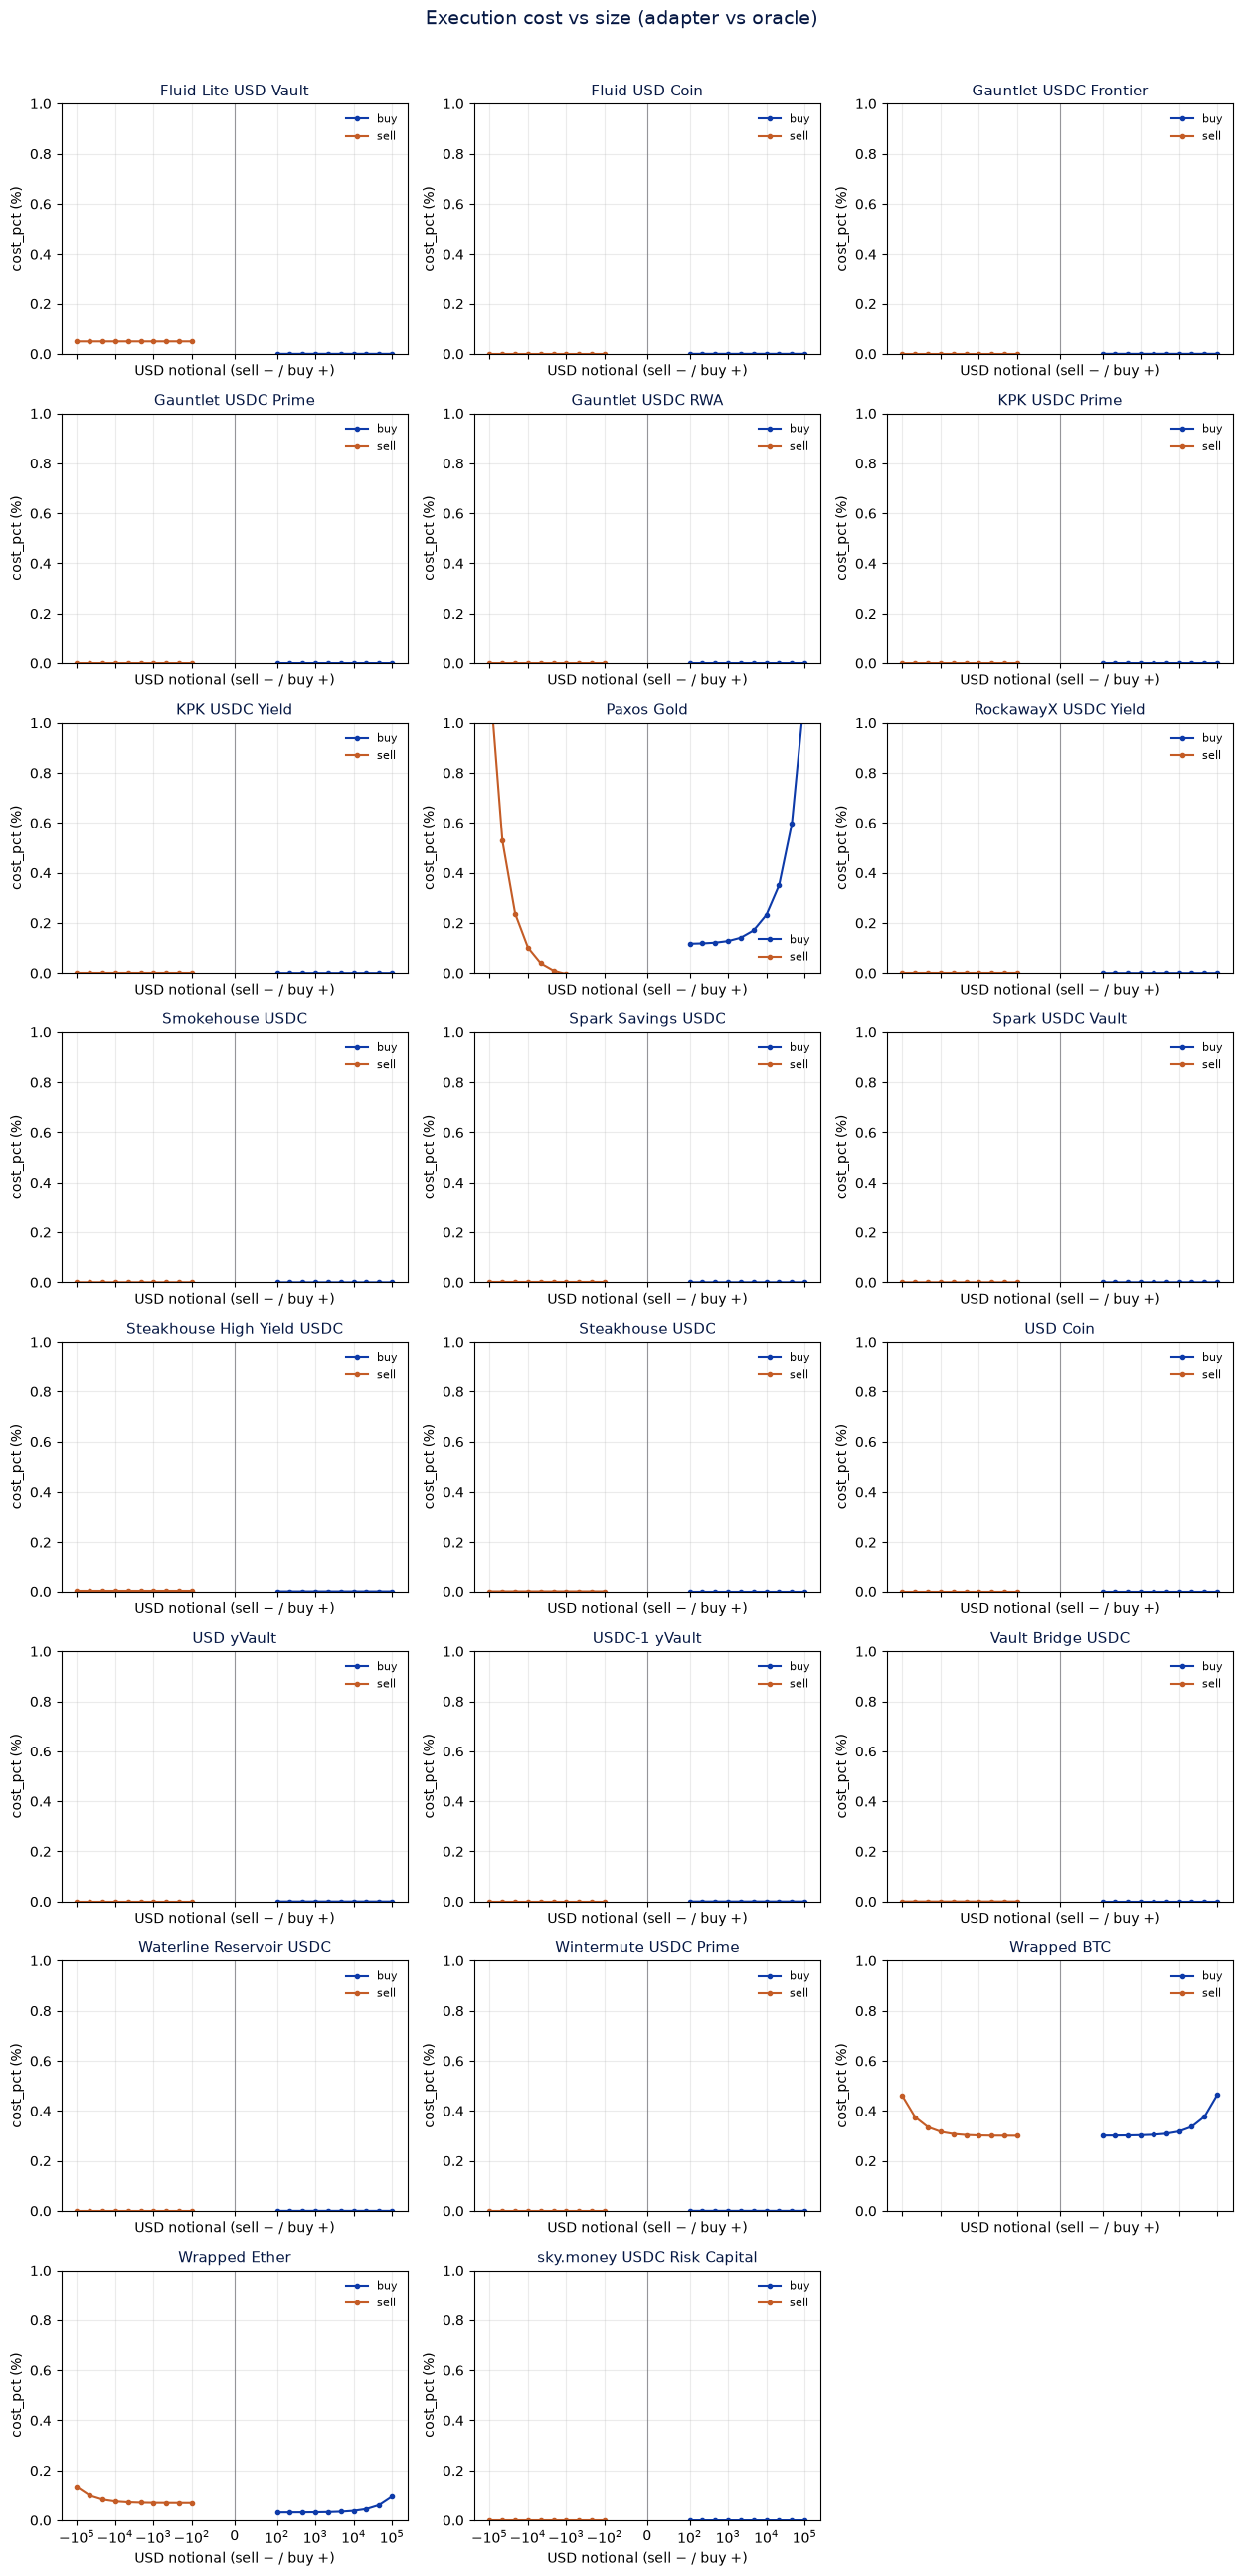

In [22]:
if curves.empty:
    raise RuntimeError("No successful quotes — check MAINNET_RPC_URL / adapters / whitelist.")

symbols = sorted(curves["symbol"].unique())
n = len(symbols)
ncols = 3 if n > 3 else max(n, 1)
nrows = int(math.ceil(n / ncols))
side_style = {"buy": BLUE, "sell": ORANGE}
# Sell → negative USD notional; buy stays positive.
signed = curves.assign(
    usd_signed=lambda d: np.where(d["side"] == "sell", -d["usd_notional"], d["usd_notional"])
)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharex=True)
axes_arr = np.atleast_1d(axes).ravel()
for ax, symbol in zip(axes_arr, symbols, strict=False):
    d_sym = signed[signed["symbol"] == symbol]
    for side, color in side_style.items():
        d = d_sym[d_sym["side"] == side].sort_values("usd_signed")
        if d.empty:
            continue
        ax.plot(
            d["usd_signed"],
            d["cost_pct"] * 100.0,
            marker="o",
            markersize=3,
            color=color,
            label=side,
        )
    ax.axvline(0.0, color=MUTED, linewidth=0.8, alpha=0.6)
    ax.set_xscale("symlog", linthresh=float(USD_NOTIONALS[0]))
    ax.set_ylim(0, 1.0)
    ax.set_title(symbol, color=NAVY, fontsize=11)
    ax.set_xlabel("USD notional (sell − / buy +)")
    ax.set_ylabel("cost_pct (%)")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8, frameon=False)
for ax in axes_arr[n:]:
    ax.set_visible(False)
fig.suptitle(
    "Execution cost vs size (adapter vs oracle)",
    color=NAVY,
    fontsize=14,
    y=1.01,
)
fig.tight_layout()
plt.show()
